Ad = 


3×3 Matrix{Float64}:
  0.999845     0.0995321  0.00452419
 -0.00452419   0.986273   0.0859596
 -0.0859596   -0.262403   0.728394

Bd = 


3×1 Matrix{Float64}:
 0.00015465307026467172
 0.004524187090179798
 0.08595955471341617

Cd = 

1×3 Matrix{Float64}:
 1.0  0.0  0.0



Observer gain L = 


3×1 adjoint(::Matrix{Float64}) with eltype Float64:
  2.114512254107879
 12.150909284477518
 15.491449424469044

eig(Ad - L*Cd) = [0.09999999999997318, 0.20000000000004542, 0.2999999999999815]


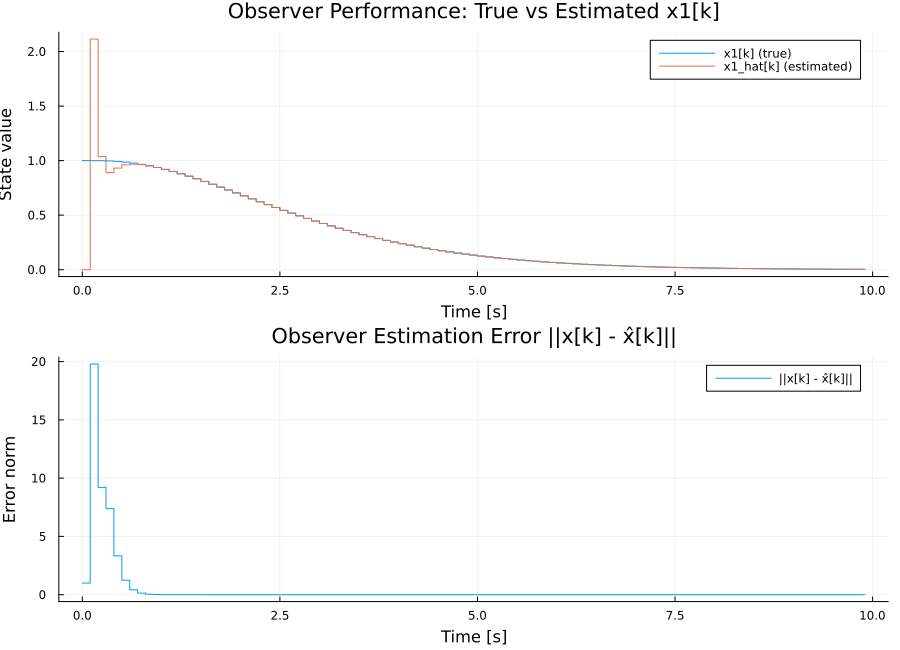

In [13]:
begin
    using LinearAlgebra
    using ControlSystems
    using Plots
    gr()  # good backend for Pluto

    # ------------------------------------------------------------
    # STEP 1 — Continuous model (same as your Python + SciPy files)
    # ------------------------------------------------------------
    A = [0.0  1.0  0.0;
         0.0  0.0  1.0;
        -1.0 -3.0 -3.0]

    B = [0.0; 0.0; 1.0]
    C = [1.0 0.0 0.0]
    D = 0.0

    Ts = 0.1

    # ------------------------------------------------------------
    # STEP 2 — Discretize using ZOH (like cont2discrete/c2d)
    # ------------------------------------------------------------
    sys_c = ss(A, B, C, D)
    sys_d = c2d(sys_c, Ts, :zoh)

    Ad, Bd, Cd = sys_d.A, sys_d.B, sys_d.C

    println("Ad = "); display(Ad)
    println("Bd = "); display(Bd)
    println("Cd = "); display(Cd)

    # ------------------------------------------------------------
    # STEP 3 — Observer gain L via pole placement (duality)
    # Want eig(Ad - L*Cd) = [0.1, 0.2, 0.3]
    # ------------------------------------------------------------
    p_obs = [0.1, 0.2, 0.3]
    L = place(Ad', Cd', p_obs)'   # same idea as: place_poles(Ad.T, Cd.T, p_obs).gain_matrix.T

    println("\nObserver gain L = "); display(L)
    println("eig(Ad - L*Cd) = ", eigvals(Ad - L*Cd))

    # ------------------------------------------------------------
    # STEP 4 — Simulate true system and observer (ZERO input)
    # matches your Python-control and SciPy observer simulation
    # x[k+1]    = Ad x[k] + Bd u,  u=0
    # xhat[k+1] = Ad xhat[k] + Bd u + L (y - yhat)
    # ------------------------------------------------------------
    steps = 100
    t_disc = (0:steps-1) .* Ts

    x    = zeros(3, steps)
    xhat = zeros(3, steps)

    x[:, 1]    = [1.0, 0.0, 0.0]     # true initial state
    xhat[:, 1] = [0.0, 0.0, 0.0]     # initial estimate

    u = 0.0

    for k in 1:steps-1
        # true plant
        x[:, k+1] = Ad*x[:, k] + Bd .* u
        yk = (Cd*x[:, k])[1]

        # observer
        yhatk = (Cd*xhat[:, k])[1]
        ek = yk - yhatk
        xhat[:, k+1] = Ad*xhat[:, k] + Bd .* u + L .* ek
    end

    # ------------------------------------------------------------
    # STEP 5 — Plots (same as your Python/SciPy)
    # Plot true vs estimated x1 and error norm
    # ------------------------------------------------------------
    p1 = plot(t_disc, x[1, :], seriestype=:step, label="x1[k] (true)",
              xlabel="Time [s]", ylabel="State value",
              title="Observer Performance: True vs Estimated x1[k]",
              grid=true)
    plot!(p1, t_disc, xhat[1, :], seriestype=:step, label="x1_hat[k] (estimated)")

    err = [norm(x[:,k] - xhat[:,k]) for k in 1:steps]
    p2 = plot(t_disc, err, seriestype=:step, label="||x[k] - x̂[k]||",
              xlabel="Time [s]", ylabel="Error norm",
              title="Observer Estimation Error ||x[k] - x̂[k]||",
              grid=true)

    plot(p1, p2, layout=(2,1), size=(900,650))  # <-- MUST be last line in Pluto
end


STEP 1: Continuous-time model created.

STEP 2: Discrete-time matrices (ZOH):
Ad =
[0.99984535 0.09953212 0.00452419; -0.00452419 0.98627279 0.08595955; -0.08595955 -0.26240285 0.72839412]
Bd =
[0.00015465; 0.00452419; 0.08595955;;]
Cd =
[1.0 0.0 0.0]
Dd =
[0.0;;]
Ts = 0.1

STEP 3: Eigenvalues of Ad:
ComplexF64[0.90483593 + 0.0im, 0.90483816 - 1.29e-6im, 0.90483816 + 1.29e-6im]
Magnitudes |eig(Ad)|: [0.90483593, 0.90483816, 0.90483816]

STEP 4: rank(ctrb(Ad,Bd)) = 3

STEP 5: State Feedback Gain K:
[68.622979 44.358493 8.180747]

STEP 6: Closed-loop eigenvalues:
[0.5, 0.6, 0.7]


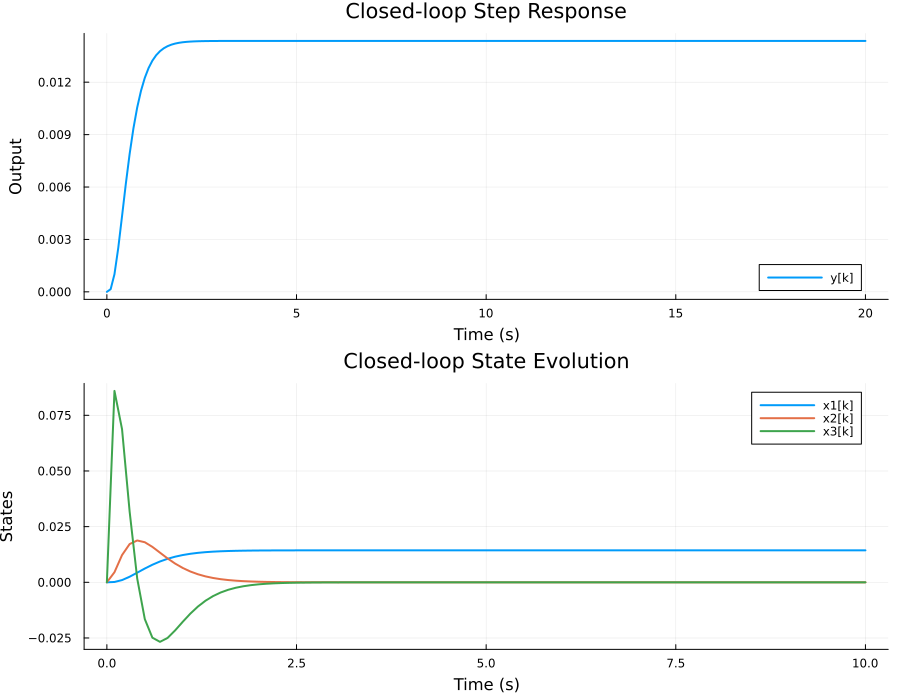

In [11]:
begin
    using LinearAlgebra
    using ControlSystems
    using Plots
    gr()

    A = [0.0 1.0 0.0;
         0.0 0.0 1.0;
        -1.0 -3.0 -3.0]
    B = [0.0; 0.0; 1.0]
    C = [1.0 0.0 0.0]
    D = 0.0

    sys_c = ss(A, B, C, D)
    println("STEP 1: Continuous-time model created.")

    Ts = 0.1
    sys_d = c2d(sys_c, Ts, :zoh)

    Ad, Bd, Cd, Dd = sys_d.A, sys_d.B, sys_d.C, sys_d.D

    println("\nSTEP 2: Discrete-time matrices (ZOH):")
    println("Ad =\n", round.(Ad; digits=8))
    println("Bd =\n", round.(Bd; digits=8))
    println("Cd =\n", Cd)
    println("Dd =\n", Dd)
    println("Ts = ", Ts)

    eigAd = eigvals(Ad)
    println("\nSTEP 3: Eigenvalues of Ad:")
    println(round.(eigAd; digits=8))
    println("Magnitudes |eig(Ad)|: ", round.(abs.(eigAd); digits=8))

    println("\nSTEP 4: rank(ctrb(Ad,Bd)) = ", rank(ctrb(Ad, Bd)))

    desired_poles = [0.5, 0.6, 0.7]
    K = place(Ad, Bd, desired_poles)
    println("\nSTEP 5: State Feedback Gain K:")
    println(round.(K; digits=6))

    Acl = Ad - Bd*K
    eigAcl = eigvals(Acl)
    println("\nSTEP 6: Closed-loop eigenvalues:")
    println(round.(eigAcl; digits=8))

    sys_cl = ss(Acl, Bd, Cd, Dd, Ts)

    y_step, t_step = step(sys_cl)
    p1 = plot(t_step, vec(y_step), linewidth=2, label="y[k]")
    xlabel!(p1, "Time (s)")
    ylabel!(p1, "Output")
    title!(p1, "Closed-loop Step Response")

    t = collect(0:Ts:10.0)
    N = length(t)
    u = ones(1, N)
    x0 = [0.0, 0.0, 0.0]

    y, tt, x = lsim(sys_cl, u, t; x0=x0)

    p2 = plot(tt, x[1, :], label="x1[k]", linewidth=2)
    plot!(p2, tt, x[2, :], label="x2[k]", linewidth=2)
    plot!(p2, tt, x[3, :], label="x3[k]", linewidth=2)
    xlabel!(p2, "Time (s)")
    ylabel!(p2, "States")
    title!(p2, "Closed-loop State Evolution")

    plot(p1, p2, layout=(2,1), size=(900,700))
end


STEP 1: Continuous-time model created (A,B,C,D).

STEP 2: Discrete-time matrices (ZOH):
Ad =
[0.9998453469297356 0.09953211598395559 0.004524187090179799; -0.004524187090179799 0.9862727856591958 0.08595955471341615; -0.0859595547134162 -0.2624028512304284 0.7283941215189474]
Bd =
[0.00015465307026467172; 0.004524187090179798; 0.08595955471341617;;]
Cd =
[1.0 0.0 0.0]
Dd =
[0.0;;]
Ts = 0.1

STEP 3: Eigenvalues of Ad: ComplexF64[0.9048359298882681 + 0.0im, 0.9048381621098064 - 1.288797298473776e-6im, 0.9048381621098064 + 1.288797298473776e-6im]
Magnitudes |eig(Ad)|: [0.9048359298882681, 0.9048381621107242, 0.9048381621107242]

STEP 4: Zero-input discrete simulation done.


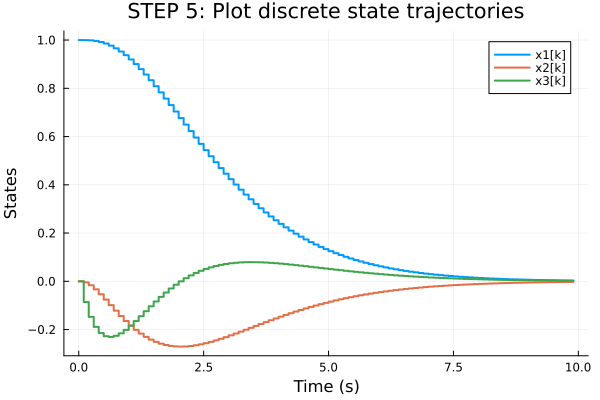

In [9]:
begin
    using LinearAlgebra
    using ControlSystems
    using Plots
    gr()

    A = [0.0 1.0 0.0;
         0.0 0.0 1.0;
        -1.0 -3.0 -3.0]
    B = [0.0; 0.0; 1.0]
    C = [1.0 0.0 0.0]
    D = 0.0

    sys_c = ss(A,B,C,D)
    println("STEP 1: Continuous-time model created (A,B,C,D).")

    Ts = 0.1
    sys_d = c2d(sys_c, Ts, :zoh)
    Ad, Bd, Cd, Dd = sys_d.A, sys_d.B, sys_d.C, sys_d.D

    println("\nSTEP 2: Discrete-time matrices (ZOH):")
    println("Ad =\n", Ad)
    println("Bd =\n", Bd)
    println("Cd =\n", Cd)
    println("Dd =\n", Dd)
    println("Ts = ", Ts)

    eigAd = eigvals(Ad)
    println("\nSTEP 3: Eigenvalues of Ad: ", eigAd)
    println("Magnitudes |eig(Ad)|: ", abs.(eigAd))

    steps = 100
    x0 = [1.0, 0.0, 0.0]
    X = zeros(3, steps)
    X[:,1] = x0

    for k in 1:(steps-1)
        X[:,k+1] = Ad * X[:,k]
    end
    println("\nSTEP 4: Zero-input discrete simulation done.")

    t = (0:steps-1) .* Ts
    p = plot(t, X[1,:], label="x1[k]", linetype=:steppost, linewidth=2)
    plot!(p, t, X[2,:], label="x2[k]", linetype=:steppost, linewidth=2)
    plot!(p, t, X[3,:], label="x3[k]", linetype=:steppost, linewidth=2)
    xlabel!(p, "Time (s)")
    ylabel!(p, "States")
    title!(p, "STEP 5: Plot discrete state trajectories")
    p
end


Eigenvalues of A: ComplexF64[-1.0000044939738566 - 7.783943406047174e-6im, -1.0000044939738566 + 7.783943406047174e-6im, -0.9999910120522852 + 0.0im]
Rank of controllability matrix: 3
Rank of observability matrix: 3


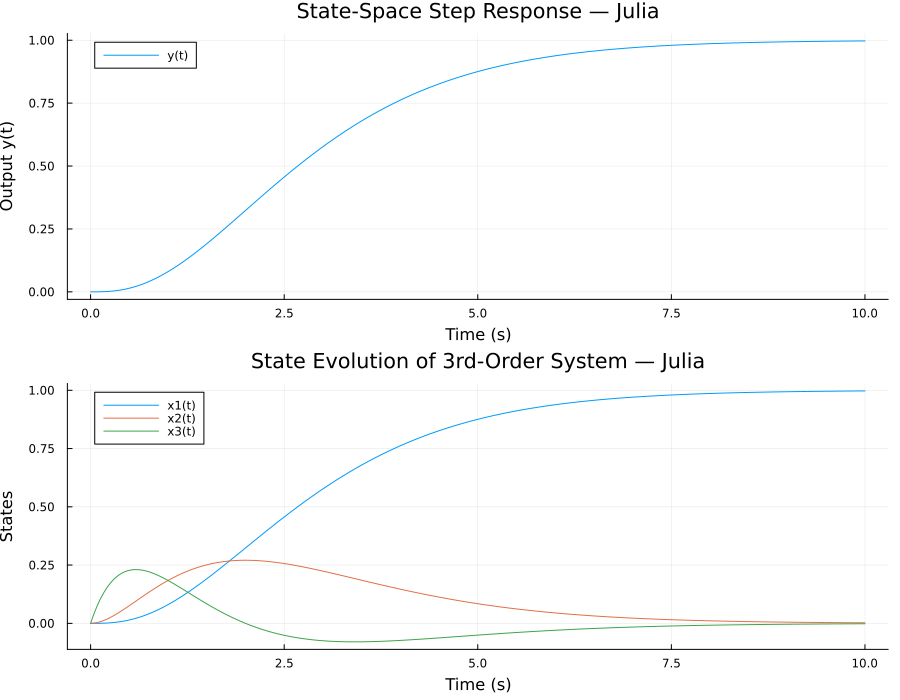

In [7]:
begin
    using LinearAlgebra

    # --- State-space model (same as ACS / Python / SciPy) ---
    A = [0.0 1.0 0.0;
         0.0 0.0 1.0;
        -1.0 -3.0 -3.0]

    B = [0.0; 0.0; 1.0]
    C = [1.0 0.0 0.0]
    D = 0.0

    sys_ss = ss(A, B, C, D)

    # --- Step response y(t) ---
    tss = 0:0.02:10
    yss, t_out = step(sys_ss, tss)

    p1 = plot(t_out, vec(yss),
              title="State-Space Step Response — Julia",
              xlabel="Time (s)", ylabel="Output y(t)",
              grid=true, label="y(t)")

    # --- State evolution x1,x2,x3 for step input u(t)=1 ---
    u = ones(Float64, 1, length(tss))     # 1×N (SISO input format)
    y_lsim, t_lsim, x = lsim(sys_ss, u, tss)   # x is 3×N

    p2 = plot(t_lsim, x[1, :], label="x1(t)",
              title="State Evolution of 3rd-Order System — Julia",
              xlabel="Time (s)", ylabel="States",
              grid=true)
    plot!(p2, t_lsim, x[2, :], label="x2(t)")
    plot!(p2, t_lsim, x[3, :], label="x3(t)")

    # --- Eigenvalues + controllability/observability (same checks as Python/SciPy) ---
    eigA = eigvals(A)
    rc = rank(ctrb(sys_ss))
    ro = rank(obsv(sys_ss))

    # Print like your Python/SciPy output
    println("Eigenvalues of A: ", eigA)
    println("Rank of controllability matrix: ", rc)
    println("Rank of observability matrix: ", ro)

    # IMPORTANT: return the plot as the LAST line so Pluto displays it
    plot(p1, p2, layout=(2,1), size=(900,700))
end


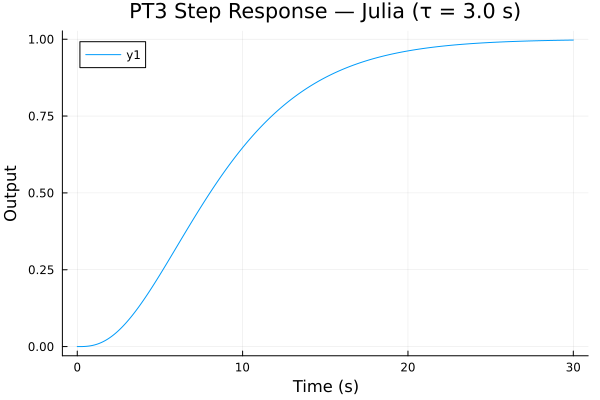

In [5]:
begin
    τ3 = 3.0
    G3 = tf(1.0, [τ3, 1.0])^3        # PT3 = (1/(τ3*s+1))^3

    t3 = 0:0.02:30
    y3, tt3 = step(G3, t3)

    plot(tt3, vec(y3),
         title="PT3 Step Response — Julia (τ = 3.0 s)",
         xlabel="Time (s)", ylabel="Output",
         grid=true)
end


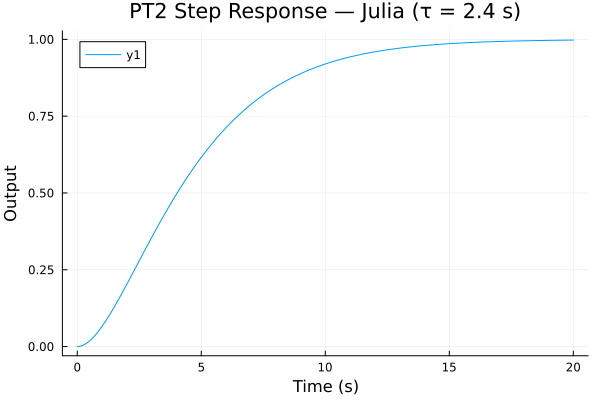

In [3]:
begin
    τ2 = 2.4
    G2 = tf(1.0, [τ2, 1.0])^2      # PT2 = (1/(τ2*s+1))^2

    t2 = 0:0.02:20
    y2, tt2 = step(G2, t2)

    plot(tt2, vec(y2),
         title="PT2 Step Response — Julia (τ = 2.4 s)",
         xlabel="Time (s)", ylabel="Output",
         grid=true)
end


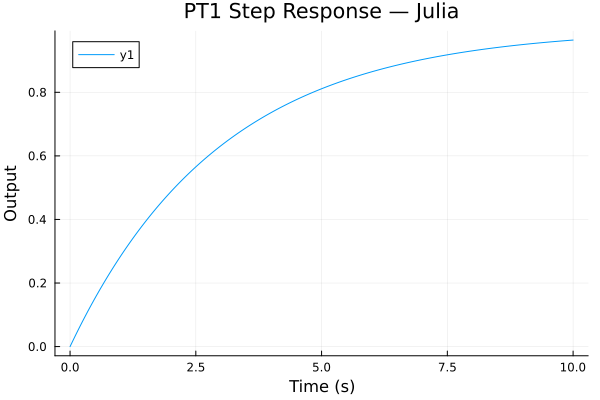

In [1]:
begin
    using ControlSystems
    using Plots

    τ = 3.0
    G1 = tf(1.0, [τ, 1.0])

    t = 0:0.02:10
    y, tt = step(G1, t)

    plot(tt, vec(y),
         title="PT1 Step Response — Julia",
         xlabel="Time (s)", ylabel="Output",
         grid=true)
end
